# 🏥 Urban Commercial Bank: EDA & Data Cleaning

This notebook processes ALL required data files and merges them into one enriched dataset.

### Full Data Pipeline:
1. **Load** `application_train.csv` — Base borrower profile
2. **Aggregate & Merge** `bureau.csv` — External debt history from other banks
3. **Aggregate & Merge** `previous_application.csv` — Past applications to THIS bank
4. **Aggregate & Merge** `installments_payments.csv` — Micro-level payment discipline ⭐
5. **Aggregate & Merge** `credit_card_balance.csv` — Credit card usage behavior
6. **Clean** Missing values, outliers
7. **Engineer** Financial ratio features
8. **Encode** Categorical columns
9. **Save** Final cleaned dataset to `data/processed/`

---
## Step 1: Imports & Load Base File (application_train.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

RAW_PATH = '../../data/raw/urban_bank/'

app_train = pd.read_csv(RAW_PATH + 'application_train.csv')
print(f"Base application_train shape: {app_train.shape}")
print(f"Default Rate: {app_train['TARGET'].mean() * 100:.2f}%")

Base application_train shape: (307511, 122)
Default Rate: 8.07%


---
## Step 2: Target Distribution

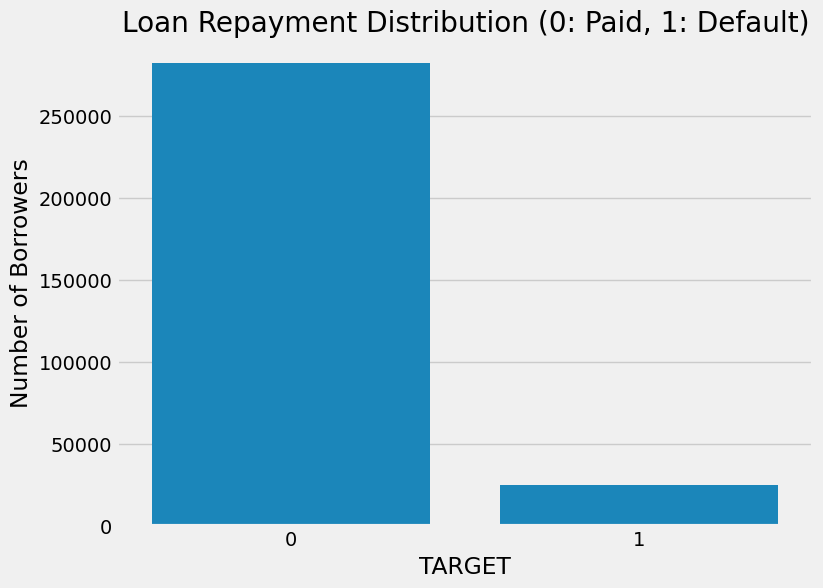

Failure to Repay: 8.07% of borrowers


In [2]:
target_counts = app_train['TARGET'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Loan Repayment Distribution (0: Paid, 1: Default)')
plt.ylabel('Number of Borrowers')
plt.show()
print(f"Failure to Repay: {target_counts[1] / len(app_train) * 100:.2f}% of borrowers")

---
## Step 3: Aggregate bureau.csv — External Debt (Other Banks)

This is the equivalent of a CIBIL / Equifax credit report check.
Each person may have 0 to many rows in this file (one per external loan).
We compress it to ONE row per person using aggregation.

In [3]:
bureau = pd.read_csv(RAW_PATH + 'bureau.csv')
print(f"bureau.csv shape: {bureau.shape}")
print(bureau.head(3))

bureau.csv shape: (1716428, 17)
   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0               1075.0                NaN   
2                   0                528.0                NaN   

   AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
0                     NaN                   0         91323.0   
1                     NaN                   0        225000.0   
2                     NaN                   0        464323.5   

   AMT_CREDIT_SUM_DEBT  AMT_CREDIT_SUM_LIMIT  AMT_CREDIT_SUM_OVERDUE  \
0                  0.0                   NaN                     0.0   
1    

In [4]:
# Count active vs closed loans per person
bureau_active = bureau[bureau['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').size().reset_index(name='BUREAU_ACTIVE_LOANS_COUNT')

# Aggregate key financial metrics per person
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_TOTAL_LOANS       = ('SK_ID_BUREAU', 'count'),
    BUREAU_TOTAL_DEBT        = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_MAX_OVERDUE_DEBT  = ('AMT_CREDIT_SUM_OVERDUE', 'max'),
    BUREAU_MEAN_DEBT         = ('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AVG_CREDIT_DAYS   = ('DAYS_CREDIT', 'mean'),      # How long they've been borrowing
    BUREAU_MAX_OVERDUE_DAYS  = ('CREDIT_DAY_OVERDUE', 'max') # Worst late payment at another bank
).reset_index()

# Merge active loans count
bureau_agg = bureau_agg.merge(bureau_active, on='SK_ID_CURR', how='left')
bureau_agg['BUREAU_ACTIVE_LOANS_COUNT'].fillna(0, inplace=True)

print(f"Bureau aggregated shape: {bureau_agg.shape}")
bureau_agg.head(3)

Bureau aggregated shape: (305811, 8)


,SK_ID_CURR,BUREAU_TOTAL_LOANS,BUREAU_TOTAL_DEBT,BUREAU_MAX_OVERDUE_DEBT,BUREAU_MEAN_DEBT,BUREAU_AVG_CREDIT_DAYS,BUREAU_MAX_OVERDUE_DAYS,BUREAU_ACTIVE_LOANS_COUNT
0,100001,7,1453365.000,0.0,207623.571429,-735.00,0,3.0
1,100002,8,865055.565,0.0,108131.945625,-874.00,0,2.0
2,100003,4,1017400.500,0.0,254350.125000,-1400.75,0,1.0


---
## Step 4: Aggregate previous_application.csv — Internal Bank History

Has this person applied to THIS bank before? Were they approved or rejected?
Being repeatedly rejected is a strong risk signal.

In [5]:
prev_app = pd.read_csv(RAW_PATH + 'previous_application.csv')
print(f"previous_application.csv shape: {prev_app.shape}")
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

previous_application.csv shape: (1670214, 37)
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [6]:
# Count approved and refused applications separately
prev_approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size().reset_index(name='PREV_APPROVED_COUNT')
prev_refused  = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size().reset_index(name='PREV_REFUSED_COUNT')

prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_TOTAL_APPS          = ('SK_ID_PREV', 'count'),
    PREV_AVG_CREDIT          = ('AMT_CREDIT', 'mean'),     # Average loan they asked for
    PREV_AVG_ANNUITY         = ('AMT_ANNUITY', 'mean'),    # Average EMI they agreed to
    PREV_MAX_DAYS_DECISION   = ('DAYS_DECISION', 'max'),   # How recently they applied
).reset_index()

prev_agg = prev_agg.merge(prev_approved, on='SK_ID_CURR', how='left')
prev_agg = prev_agg.merge(prev_refused,  on='SK_ID_CURR', how='left')
prev_agg[['PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT']] = prev_agg[['PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT']].fillna(0)

# Rejection rate — very useful feature
prev_agg['PREV_REFUSAL_RATE'] = prev_agg['PREV_REFUSED_COUNT'] / (prev_agg['PREV_TOTAL_APPS'] + 1e-5)

print(f"Previous apps aggregated shape: {prev_agg.shape}")
prev_agg.head(3)

Previous apps aggregated shape: (338857, 8)


,SK_ID_CURR,PREV_TOTAL_APPS,PREV_AVG_CREDIT,PREV_AVG_ANNUITY,PREV_MAX_DAYS_DECISION,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_REFUSAL_RATE
0,100001,1,23787.0,3951.000,-1740,1.0,0.0,0.0
1,100002,1,179055.0,9251.775,-606,1.0,0.0,0.0
2,100003,3,484191.0,56553.990,-746,3.0,0.0,0.0


---
## Step 5: Aggregate installments_payments.csv — Payment Discipline ⭐ Most Important!

This is the most powerful signal. It shows **how late** a person pays their bills.
- `DAYS_INSTALMENT` = When they SHOULD have paid
- `DAYS_ENTRY_PAYMENT` = When they ACTUALLY paid
- Difference = Days Late (negative means early, positive means late)

In [7]:
installments = pd.read_csv(RAW_PATH + 'installments_payments.csv')
print(f"installments_payments.csv shape: {installments.shape}")
print(installments.head(3))

installments_payments.csv shape: (13605401, 8)
   SK_ID_PREV  SK_ID_CURR  NUM_INSTALMENT_VERSION  NUM_INSTALMENT_NUMBER  \
0     1054186      161674                     1.0                      6   
1     1330831      151639                     0.0                     34   
2     2085231      193053                     2.0                      1   

   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  AMT_INSTALMENT  AMT_PAYMENT  
0          -1180.0             -1187.0        6948.360     6948.360  
1          -2156.0             -2156.0        1716.525     1716.525  
2            -63.0               -63.0       25425.000    25425.000  


In [8]:
# Calculate days late per payment (positive = late, negative = early)
# Both are stored as negative days from today, so we subtract to get the gap
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

# Calculate how much they paid vs what was due (payment ratio)
installments['PAYMENT_RATIO'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + 1e-5)

instal_agg = installments.groupby('SK_ID_CURR').agg(
    INSTAL_COUNT             = ('SK_ID_PREV', 'count'),       # How many total payments
    INSTAL_AVG_DAYS_LATE     = ('DAYS_LATE', 'mean'),         # ⭐ Average days late
    INSTAL_MAX_DAYS_LATE     = ('DAYS_LATE', 'max'),          # ⭐ Worst late payment ever
    INSTAL_LATE_PAYMENTS     = ('DAYS_LATE', lambda x: (x > 0).sum()), # Count of late payments
    INSTAL_AVG_PAYMENT_RATIO = ('PAYMENT_RATIO', 'mean'),     # Did they pay the full amount?
    INSTAL_MIN_PAYMENT_RATIO = ('PAYMENT_RATIO', 'min'),      # Worst underpayment
).reset_index()

# Late payment rate
instal_agg['INSTAL_LATE_RATE'] = instal_agg['INSTAL_LATE_PAYMENTS'] / (instal_agg['INSTAL_COUNT'] + 1e-5)

print(f"Installments aggregated shape: {instal_agg.shape}")
instal_agg.head(3)

Installments aggregated shape: (339587, 8)


,SK_ID_CURR,INSTAL_COUNT,INSTAL_AVG_DAYS_LATE,INSTAL_MAX_DAYS_LATE,INSTAL_LATE_PAYMENTS,INSTAL_AVG_PAYMENT_RATIO,INSTAL_MIN_PAYMENT_RATIO,INSTAL_LATE_RATE
0,100001,7,-7.285714,11.0,1,1.0,1.0,0.142857
1,100002,19,-20.421053,-12.0,0,1.0,1.0,0.000000
2,100003,25,-7.160000,-1.0,0,1.0,1.0,0.000000


---
## Step 6: Aggregate credit_card_balance.csv — Credit Card Behavior

In [9]:
cc_balance = pd.read_csv(RAW_PATH + 'credit_card_balance.csv')
print(f"credit_card_balance.csv shape: {cc_balance.shape}")
print(cc_balance.head(3))

credit_card_balance.csv shape: (3840312, 23)
   SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  AMT_BALANCE  \
0     2562384      378907              -6       56.970   
1     2582071      363914              -1    63975.555   
2     1740877      371185              -7    31815.225   

   AMT_CREDIT_LIMIT_ACTUAL  AMT_DRAWINGS_ATM_CURRENT  AMT_DRAWINGS_CURRENT  \
0                   135000                       0.0                 877.5   
1                    45000                    2250.0                2250.0   
2                   450000                       0.0                   0.0   

   AMT_DRAWINGS_OTHER_CURRENT  AMT_DRAWINGS_POS_CURRENT  \
0                         0.0                     877.5   
1                         0.0                       0.0   
2                         0.0                       0.0   

   AMT_INST_MIN_REGULARITY  ...  AMT_RECIVABLE  AMT_TOTAL_RECEIVABLE  \
0                 1700.325  ...          0.000                 0.000   
1                 2250.000  

In [10]:
cc_agg = cc_balance.groupby('SK_ID_CURR').agg(
    CC_COUNT                 = ('SK_ID_PREV', 'count'),
    CC_AVG_BALANCE           = ('AMT_BALANCE', 'mean'),
    CC_MAX_BALANCE           = ('AMT_BALANCE', 'max'),
    CC_AVG_CREDIT_LIMIT      = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    CC_MAX_DRAWINGS          = ('AMT_DRAWINGS_CURRENT', 'max'),    # How much they withdraw
    CC_TOTAL_LATE_PAYMENTS   = ('SK_DPD', 'sum'),                  # Total days past due
    CC_MAX_LATE_PAYMENT      = ('SK_DPD', 'max'),                  # Worst late payment
).reset_index()

# Credit Utilisation Ratio — how much of their credit limit are they using?
# High utilisation > 80% is a risk signal
cc_agg['CC_UTILISATION_RATIO'] = cc_agg['CC_AVG_BALANCE'] / (cc_agg['CC_AVG_CREDIT_LIMIT'] + 1e-5)

print(f"Credit card aggregated shape: {cc_agg.shape}")
cc_agg.head(3)

Credit card aggregated shape: (103558, 9)


,SK_ID_CURR,CC_COUNT,CC_AVG_BALANCE,CC_MAX_BALANCE,CC_AVG_CREDIT_LIMIT,CC_MAX_DRAWINGS,CC_TOTAL_LATE_PAYMENTS,CC_MAX_LATE_PAYMENT,CC_UTILISATION_RATIO
0,100006,6,0.000000,0.00,270000.000000,0.0,0,0,0.000000
1,100011,74,54482.111149,189000.00,164189.189189,180000.0,0,0,0.331825
2,100013,96,18159.919219,161420.22,131718.750000,157500.0,1,1,0.137869


---
## Step 7: Merge All Files Into One Enriched Dataset

All supplementary tables are merged using a **LEFT JOIN** on `SK_ID_CURR`.
Left join ensures we keep ALL applicants, even those without credit card history etc.

In [11]:
print(f"Shape before merging: {app_train.shape}")

df = app_train.copy()
df = df.merge(bureau_agg,  on='SK_ID_CURR', how='left')
df = df.merge(prev_agg,    on='SK_ID_CURR', how='left')
df = df.merge(instal_agg,  on='SK_ID_CURR', how='left')
df = df.merge(cc_agg,      on='SK_ID_CURR', how='left')

print(f"Shape after merging all files: {df.shape}")
print(f"Added {df.shape[1] - app_train.shape[1]} new features from supplementary files!")

Shape before merging: (307511, 122)
Shape after merging all files: (307511, 151)
Added 29 new features from supplementary files!


---
## Step 8: Handle Missing Values

In [12]:
# --- 8a. Drop columns with > 40% missing that are not critical ---
cols_to_drop = ['EMERGENCYSTATE_MODE', 'TOTALAREA_MODE']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# --- 8b. Bureau query columns: missing = never queried = 0 ---
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
df[bureau_cols] = df[bureau_cols].fillna(0)

# --- 8c. Social circle columns: missing = 0 ---
social_cols = [
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'
]
df[social_cols] = df[social_cols].fillna(0)

# --- 8d. Fill numerical core columns with median ---
num_cols = ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# --- 8e. Categorical fills ---
df['NAME_TYPE_SUITE'].fillna(df['NAME_TYPE_SUITE'].mode()[0], inplace=True)
df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

# --- 8f. All NEW merged columns: missing = 0 (person has no such history) ---
# Bureau, previous app, installments, credit card — if a person has no history, fill with 0
new_cols = [c for c in df.columns if c.startswith(('BUREAU_', 'PREV_', 'INSTAL_', 'CC_'))]
df[new_cols] = df[new_cols].fillna(0)

print(f"Missing values after treatment: {df.isnull().sum().sum()}")

Missing values after treatment: 8272102


---
## Step 9: Outlier Removal

In [13]:
# DAYS_EMPLOYED anomaly: 365243 = placeholder for 'pensioner / not employed'
print(f"DAYS_EMPLOYED anomaly count: {(df['DAYS_EMPLOYED'] == 365243).sum()}")
df['DAYS_EMPLOYED'].replace(365243, 0, inplace=True)

# Convert all DAYS_* columns to positive (they are stored as negatives)
days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
for col in days_cols:
    if col in df.columns:
        df[col] = df[col].abs()

print("Outlier treatment complete.")

DAYS_EMPLOYED anomaly count: 55374
Outlier treatment complete.


---
## Step 10: Feature Engineering — Financial Ratios

In [15]:
# Core financial ratios from application_train
df['ANNUITY_INCOME_PERCENT']  = df['AMT_ANNUITY']  / df['AMT_INCOME_TOTAL']       # DTI
df['CREDIT_INCOME_PERCENT']   = df['AMT_CREDIT']   / df['AMT_INCOME_TOTAL']       # Loan vs Salary
df['CREDIT_TERM']             = df['AMT_ANNUITY']  / (df['AMT_CREDIT'] + 1e-5)   # Loan duration proxy
df['DAYS_EMPLOYED_PERCENT']   = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1e-5)  # Employment stability
df['AGE_YEARS']               = df['DAYS_BIRTH'] // 365                           # Age in years

# Combined external score (average of 3 credit scores — very strong predictor)
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_MIN']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)

print("Feature engineering complete.")
print(df[['ANNUITY_INCOME_PERCENT', 'CREDIT_INCOME_PERCENT', 'AGE_YEARS', 'EXT_SOURCE_MEAN']].describe().round(3))

Feature engineering complete.
       ANNUITY_INCOME_PERCENT  CREDIT_INCOME_PERCENT   AGE_YEARS  \
count              307511.000             307511.000  307511.000   
mean                    0.181                  3.958      43.436   
std                     0.095                  2.690      11.955   
min                     0.000                  0.005      20.000   
25%                     0.115                  2.019      34.000   
50%                     0.163                  3.265      43.000   
75%                     0.229                  5.160      53.000   
max                     1.876                 84.737      69.000   

       EXT_SOURCE_MEAN  
count       307511.000  
mean             0.512  
std              0.108  
min              0.024  
25%              0.442  
50%              0.522  
75%              0.588  
max              0.853  


---
## Step 11: Select Features & Encode Categoricals

In [16]:
# --- Drop ID and non-predictive columns ---
drop_cols = ['SK_ID_CURR']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# --- Label Encode binary categorical columns (2 unique values) ---
le = LabelEncoder()
binary_cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in binary_cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# --- One-Hot Encode multi-category columns ---
multi_cat_cols = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE',
    'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE'
]
multi_cat_cols = [c for c in multi_cat_cols if c in df.columns]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"Final shape after encoding: {df.shape}")

Final shape after encoding: (307511, 263)


---
## Step 12: Final Cleanup & Save

In [17]:
# Replace any infinite values and fill any leftover NaNs with 0
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

final_missing = df.isnull().sum().sum()
print(f"Total remaining NaN values: {final_missing}")
print(f"Final Dataset Shape: {df.shape}")
print(f"Features for model training: {df.shape[1] - 1}")

# Save to processed folder
output_dir = '../../data/processed/urban_bank/'
os.makedirs(output_dir, exist_ok=True)
output_path = output_dir + 'cleaned_application.csv'
df.to_csv(output_path, index=False)

print(f"\n✅ DONE! Saved cleaned dataset to: {output_path}")

Total remaining NaN values: 0
Final Dataset Shape: (307511, 263)
Features for model training: 262

✅ DONE! Saved cleaned dataset to: ../../data/processed/urban_bank/cleaned_application.csv
